# Lecture 07 – Introducción a Deep Learning
### Universidad EAFIT | 2026 - Introducción a la IA

---

## ¿Qué es Deep Learning?

Las **redes neuronales** son modelos de Machine Learning que aprenden representaciones a partir de datos ajustando parámetros distribuidos en capas interconectadas.

### Deep Learning vs. Machine Learning Tradicional

En el **Machine Learning tradicional**, un experto humano suele diseñar manualmente las features relevantes:

```text
Raw Input → Feature Engineering (humano) → Features → Modelo ML → Output
```

En **Deep Learning**, la red puede aprender automáticamente representaciones útiles a partir de los datos:

```text
Raw Input → DNN (aprende representaciones jerárquicas) → Output
```

> **La clave**: al apilar capas con transformaciones **no lineales**, la red puede aprender representaciones progresivamente más útiles para la tarea.

---

## ¿Qué construiremos en este notebook?

Implementaremos y compararemos **dos modelos con Keras 3** para clasificar imágenes del dataset **Fashion-MNIST**:

| Modelo | Descripción | Frontera de decisión |
|---|---|---|
| **Regresión Logística** | Una sola capa lineal | Lineal |
| **Red Neuronal FC** | Capa oculta + activación ReLU | No lineal |

Fashion-MNIST es más desafiante que MNIST: algunas categorías, como **Shirt**, **T-shirt/top**, **Pullover** y **Coat**, tienen apariencias similares.

Al final podremos observar cómo añadir una capa oculta con una activación no lineal aumenta la capacidad del modelo.

---


## 0. Configuración del entorno

Usaremos **Keras 3**, una API de Deep Learning que permite definir, entrenar y evaluar redes neuronales con una interfaz de alto nivel.

Keras 3 es **multi-backend**: puede trabajar sobre backends compatibles como TensorFlow, JAX o PyTorch. En este notebook utilizaremos exclusivamente la API pública de `keras`.

> A diferencia de PyTorch, en este ejemplo no moveremos manualmente el modelo con `.to(device)`. El backend seleccionado por Keras gestiona la ejecución sobre CPU/GPU según el entorno.


In [1]:
import keras
from keras import layers
import matplotlib.pyplot as plt
import numpy as np

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


Keras version : 3.15.1
Backend       : tensorflow


---
## 1. Carga del Dataset: Fashion-MNIST

**Fashion-MNIST** contiene imágenes de prendas de vestir y calzado:

- **60,000 imágenes** para entrenamiento
- **10,000 imágenes** para prueba
- Cada imagen tiene **28×28 píxeles** en escala de grises
- **10 clases**

| Etiqueta | Clase |
|---:|---|
| 0 | T-shirt/top |
| 1 | Trouser |
| 2 | Pullover |
| 3 | Dress |
| 4 | Coat |
| 5 | Sandal |
| 6 | Shirt |
| 7 | Sneaker |
| 8 | Bag |
| 9 | Ankle boot |

### Representación de una imagen como vector de features

Las imágenes originales contienen intensidades entre 0 y 255. Las normalizamos al rango **[0, 1]**:

$$x_{\text{norm}} = \frac{x}{255}$$

Nuestros modelos fully-connected recibirán cada imagen como un vector de:

$$28\times 28 = 784$$

features.

No es necesario hacer el `reshape` manualmente antes del entrenamiento: añadiremos una capa `Flatten()` dentro del modelo.


In [2]:
# Keras incluye Fashion-MNIST directamente.
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalización: uint8 [0,255] -> float32 [0,1]
X_train = X_train.astype("float32") / 255.0
X_test  = X_test.astype("float32") / 255.0

class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

print(f"Muestras de entrenamiento : {len(X_train)}")
print(f"Muestras de prueba        : {len(X_test)}")
print(f"Tamaño de una imagen      : {X_train[0].shape} -> (alto, ancho)")
print(f"Tipo X_train              : {X_train.dtype}")
print(f"Tipo y_train              : {y_train.dtype}")
print(f"Número de clases          : {len(class_names)}")
print(f"Clases                    : {class_names}")


    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:44 4us/step

   49152/26421880 ━━━━━━━━━━━━━━━━━━━━ 1:22 3us/step

...

      0/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

2760704/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4333568/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Muestras de entrenamiento : 60000
Muestras de prueba        : 10000
Tamaño de una imagen      : (28, 28) -> (alto, ancho)
Tipo X_train              : float32
Tipo y_train              : uint8
Número de clases          : 10
Clases                    : ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### ¿Dónde está el `DataLoader`?

Con Keras podemos entregar directamente arrays de NumPy a `model.fit()`:

```python
model.fit(
    X_train,
    y_train,
    batch_size=64,
    shuffle=True,
)
```

Keras divide los datos internamente en **mini-batches**.

Para este notebook:

| Concepto | PyTorch | Keras 3 |
|---|---|---|
| Dataset | `torchvision.datasets.FashionMNIST` | `keras.datasets.fashion_mnist.load_data()` |
| Mini-batches | `DataLoader(..., batch_size=64)` | `model.fit(..., batch_size=64)` |
| Mezclar ejemplos | `shuffle=True` en `DataLoader` | `shuffle=True` en `fit()` |
| Aplanar imagen | `images.view(-1, 784)` | `layers.Flatten()` |

### ¿Por qué usar mini-batches?

Con un batch de tamaño $B$, el modelo calcula gradientes usando $B$ ejemplos antes de actualizar sus parámetros.

- **Full-batch**: una actualización por epoch.
- **SGD puro**: una actualización por ejemplo.
- **Mini-batch**: compromiso práctico entre eficiencia computacional y ruido del gradiente.

En Fashion-MNIST usaremos:

```python
batch_size = 64
```


In [3]:
batch_size = 64

n_train_batches = int(np.ceil(len(X_train) / batch_size))
n_test_batches  = int(np.ceil(len(X_test) / batch_size))

print(f"Batches de entrenamiento : {n_train_batches}")
print(f"Batches de prueba        : {n_test_batches}")

# Simulamos el primer batch únicamente para explorar sus dimensiones.
images = X_train[:batch_size]
labels = y_train[:batch_size]

print(f"\nShape del batch de imágenes  : {images.shape}")
print(f"Shape del batch de etiquetas : {labels.shape}")
print(f"Etiquetas (primeras 10)      : {labels[:10].tolist()}")
print("Clases (primeras 10)        :", [class_names[label] for label in labels[:10]])


Batches de entrenamiento : 938
Batches de prueba        : 157

Shape del batch de imágenes  : (64, 28, 28)
Shape del batch de etiquetas : (64,)
Etiquetas (primeras 10)      : [9, 0, 0, 3, 0, 2, 7, 2, 5, 5]
Clases (primeras 10)        : ['Ankle boot', 'T-shirt/top', 'T-shirt/top', 'Dress', 'T-shirt/top', 'Pullover', 'Sneaker', 'Pullover', 'Sandal', 'Sandal']


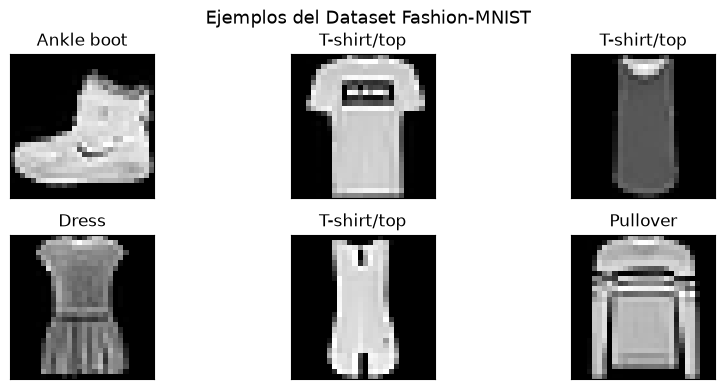

In [4]:
# Visualizamos 6 imágenes de ejemplo.
fig = plt.figure(figsize=(9, 4))

for i in range(6):
    plt.subplot(2, 3, i + 1)
    plt.tight_layout()
    plt.imshow(images[i], cmap="gray", interpolation="none")
    plt.title(class_names[labels[i]])
    plt.xticks([])
    plt.yticks([])

plt.suptitle("Ejemplos del Dataset Fashion-MNIST", fontsize=13, y=1.02)
plt.show()


---
## 2. Definición de modelos

### Revisión: del perceptrón a las redes neuronales

Para clasificación multiclase podemos transformar los **logits** $z_k$ en probabilidades usando Softmax:

$$
P(y_k\mid\mathbf{x})
=
\frac{e^{z_k}}
{\sum_{j=1}^{K}e^{z_j}}
$$

La predicción será:

$$
\hat y = \arg\max_k z_k
$$

Aplicar `argmax` sobre logits o sobre probabilidades Softmax produce la misma clase.

### Modelo 1 — Regresión logística

Arquitectura:

```text
Input(28×28) → Flatten(784) → Dense(10) → logits
```

Es un modelo **lineal** respecto a las 784 features de píxel.

### Modelo 2 — Red neuronal fully-connected

Arquitectura:

```text
Input(28×28) → Flatten(784) → Dense(128) → ReLU → Dense(10) → logits
```

La activación ReLU:

$$
g(x)=\max(0,x)
$$

introduce **no linealidad**. Sin una activación no lineal entre capas, varias capas `Dense` consecutivas seguirían representando una única transformación lineal.

En Fashion-MNIST esta mayor capacidad es especialmente útil porque varias categorías de ropa son visualmente parecidas.


In [5]:
input_shape = (28, 28)
output_dim  = 10

# =============================================================================
# MODELO 1: Regresión Logística
# Input(28,28) -> Flatten(784) -> Dense(10)
# =============================================================================
logistic_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Flatten(name="flatten"),
        layers.Dense(output_dim, name="logits"),
    ],
    name="LogisticRegression",
)

# =============================================================================
# MODELO 2: Red Fully-Connected
# Input(28,28) -> Flatten(784) -> Dense(128) -> ReLU -> Dense(10)
# =============================================================================
fc_model = keras.Sequential(
    [
        keras.Input(shape=input_shape),
        layers.Flatten(name="flatten"),
        layers.Dense(128, activation="relu", name="hidden"),
        layers.Dense(output_dim, name="logits"),
    ],
    name="FCNeuralNetwork",
)

print("Modelos definidos exitosamente.\n")
print("LogisticRegression : 784 -> Dense(10)")
print("FCNeuralNetwork    : 784 -> Dense(128) -> ReLU -> Dense(10)")


Modelos definidos exitosamente.

LogisticRegression : 784 -> Dense(10)
FCNeuralNetwork    : 784 -> Dense(128) -> ReLU -> Dense(10)


In [6]:
print("=== Regresión Logística ===")
logistic_model.summary()

print("\n=== Red Neuronal FC ===")
fc_model.summary()

print(f"\nParámetros LogisticRegression : {logistic_model.count_params():,}")
print(f"Parámetros FCNeuralNetwork    : {fc_model.count_params():,}")


=== Regresión Logística ===


Model: "LogisticRegression"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         7,850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,850 (30.66 KB)

 Trainable params: 7,850 (30.66 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ logits (Dense)                  │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


Parámetros LogisticRegression : 7,850
Parámetros FCNeuralNetwork    : 101,770


---
## 3. Configuración del entrenamiento

### Hiperparámetros

- **`epochs = 10`**: número de pasadas completas por los datos.
- **`batch_size = 64`**: ejemplos usados por actualización.
- **`lr_rate = 0.001`**: learning rate de Adam.

### Función de pérdida: Sparse Categorical Cross-Entropy

Las etiquetas de Fashion-MNIST están almacenadas como enteros entre 0 y 9. Cada entero identifica una categoría de prenda.

Por eso usaremos:

```python
keras.losses.SparseCategoricalCrossentropy(from_logits=True)
```

`from_logits=True` es importante porque la última capa produce **logits**, no probabilidades.

Conceptualmente, la pérdida incorpora la transformación Softmax necesaria para calcular la cross-entropy de forma numéricamente estable. Por eso **no añadimos `Softmax` a la última capa**.

### Optimizador: Adam

Usaremos:

```python
keras.optimizers.Adam(learning_rate=0.001)
```

Keras conectará el optimizador, la función de pérdida y las métricas mediante `model.compile()`.


In [7]:
epochs  = 10
lr_rate = 0.001

loss_fn = keras.losses.SparseCategoricalCrossentropy(
    from_logits=True
)

def compile_model(model):
    # Creamos un optimizador nuevo para cada modelo.
    optimizer = keras.optimizers.Adam(learning_rate=lr_rate)

    model.compile(
        optimizer=optimizer,
        loss=loss_fn,
        metrics=[
            keras.metrics.SparseCategoricalAccuracy(
                name="accuracy"
            )
        ],
    )

print(f"Épocas de entrenamiento : {epochs}")
print(f"Batch size              : {batch_size}")
print(f"Learning rate           : {lr_rate}")
print("Loss                    : SparseCategoricalCrossentropy(from_logits=True)")
print("Optimizer               : Adam")


Épocas de entrenamiento : 10
Batch size              : 64
Learning rate           : 0.001
Loss                    : SparseCategoricalCrossentropy(from_logits=True)
Optimizer               : Adam


### Elegimos el modelo

Cambia únicamente esta variable para repetir el experimento:

```python
MODEL_TYPE = "logistic"
```

o:

```python
MODEL_TYPE = "fc"
```


In [8]:
MODEL_TYPE = "logistic"   # "logistic" o "fc"

if MODEL_TYPE == "logistic":
    model = logistic_model
elif MODEL_TYPE == "fc":
    model = fc_model
else:
    raise ValueError("MODEL_TYPE debe ser 'logistic' o 'fc'")

compile_model(model)

print(f"Modelo seleccionado: {model.name}")
print(f"Parámetros entrenables: {model.count_params():,}")


Modelo seleccionado: LogisticRegression
Parámetros entrenables: 7,850


---
## 4. Ciclo de entrenamiento

En una implementación de bajo nivel, cada mini-batch requiere conceptualmente:

```text
1. Forward pass
2. Calcular loss
3. Calcular gradientes con backpropagation
4. Actualizar parámetros con el optimizador
```

Con Keras 3, `model.fit()` ejecuta este ciclo automáticamente:

```python
history = model.fit(...)
```

La correspondencia conceptual es:

| Concepto | Implementación manual | Keras 3 |
|---|---|---|
| Forward | `outputs = model(x)` | interno en `fit()` |
| Loss | `loss_fn(y, outputs)` | definido en `compile()` |
| Backpropagation | autodiferenciación | interno en `fit()` |
| Actualización | `optimizer.step/apply...` | interno en `fit()` |
| Mini-batches | loop explícito | `batch_size=64` |
| Epochs | loop externo | `epochs=10` |

### Backpropagation

Backpropagation usa la regla de la cadena para calcular:

$$
\frac{\partial\mathcal L}{\partial W^{(k)}}
=
\frac{\partial\mathcal L}{\partial z^{(k)}}
\frac{\partial z^{(k)}}{\partial W^{(k)}}
$$

Keras delega el cálculo automático de esos gradientes al backend seleccionado.


In [9]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=epochs,
    batch_size=batch_size,
    shuffle=True,
    verbose=1,
)


Epoch 1/10


  1/938 ━━━━━━━━━━━━━━━━━━━━ 6:18 404ms/step - accuracy: 0.0781 - loss: 2.6123

 54/938 ━━━━━━━━━━━━━━━━━━━━ 0s 945us/step - accuracy: 0.5266 - loss: 1.4529  

115/938 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.6307 - loss: 1.1341

172/938 ━━━━━━━━━━━━━━━━━━━━ 0s 885us/step - accuracy: 0.6665 - loss: 1.0151

...

712/938 ━━━━━━━━━━━━━━━━━━━━ 0s 855us/step - accuracy: 0.8630 - loss: 0.3950

767/938 ━━━━━━━━━━━━━━━━━━━━ 0s 859us/step - accuracy: 0.8632 - loss: 0.3948

825/938 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - accuracy: 0.8627 - loss: 0.3966

881/938 ━━━━━━━━━━━━━━━━━━━━ 0s 863us/step - accuracy: 0.8628 - loss: 0.3966

938/938 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8625 - loss: 0.3972 - val_accuracy: 0.8442 - val_loss: 0.4480


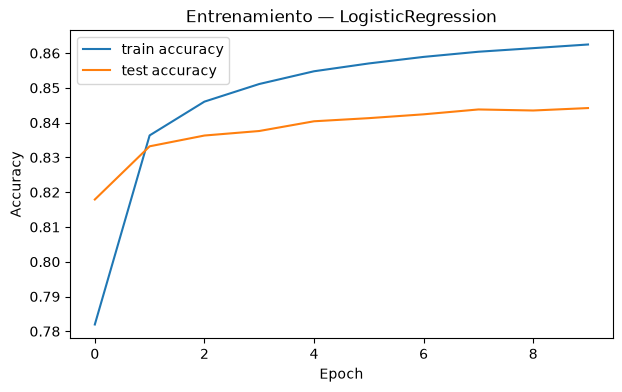

In [10]:
# Graficamos la evolución del entrenamiento.
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="train accuracy")
plt.plot(history.history["val_accuracy"], label="test accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Entrenamiento — {model.name}")
plt.legend()
plt.show()


### Logits vs. probabilidades

La última capa:

```python
layers.Dense(10)
```

no tiene activación. Por lo tanto produce **logits**.

Para interpretar esos valores como probabilidades usamos Softmax:

$$
P(y_k\mid x)
=
\frac{e^{z_k}}
{\sum_j e^{z_j}}
$$

Durante el entrenamiento no necesitamos añadir Softmax al modelo porque la loss fue configurada con `from_logits=True`.


In [11]:
# Tomamos una imagen de prueba.
sample = X_test[:1]
true_label = y_test[0]

# Forward pass directo: devuelve logits.
logits = model(sample, training=False)[0]

print("Logits:")
print(keras.ops.convert_to_numpy(logits))
print(
    f"\nSuma de logits: "
    f"{float(keras.ops.convert_to_numpy(keras.ops.sum(logits))):.4f} "
    "← NO tiene que ser 1"
)

# Convertimos logits a probabilidades.
probs = keras.ops.softmax(logits)
probs_np = keras.ops.convert_to_numpy(probs)

pred_class = int(np.argmax(probs_np))

print("\nProbabilidades (Softmax):")
for k, p in enumerate(probs_np):
    marker = " <- PREDICCIÓN" if k == pred_class else ""
    print(f"  {k}: {class_names[k]:12s} -> {p:.4f}{marker}")

print(f"\nSuma de probabilidades: {probs_np.sum():.6f}")
print(f"Clase real             : {true_label} -> {class_names[true_label]}")
print(f"Clase predicha         : {pred_class} -> {class_names[pred_class]}")


Logits:
[-7.5302563 -9.304544  -3.8491282 -4.7433796 -4.5101247  4.929886
 -3.2306378  4.3836107  1.6873935  6.3474545]

Suma de logits: -15.8197 ← NO tiene que ser 1

Probabilidades (Softmax):
  0: T-shirt/top  -> 0.0000
  1: Trouser      -> 0.0000
  2: Pullover     -> 0.0000
  3: Dress        -> 0.0000
  4: Coat         -> 0.0000
  5: Sandal       -> 0.1740
  6: Shirt        -> 0.0000
  7: Sneaker      -> 0.1008
  8: Bag          -> 0.0068
  9: Ankle boot   -> 0.7183 <- PREDICCIÓN

Suma de probabilidades: 1.000000
Clase real             : 9 -> Ankle boot
Clase predicha         : 9 -> Ankle boot


---
## 5. Evaluación del modelo

Una vez entrenado, evaluamos sobre las **10,000 imágenes de prueba**, que no se usan para actualizar los parámetros.

Con Keras:

```python
model.evaluate(X_test, y_test)
```

Durante `evaluate()` el modelo trabaja en modo inferencia automáticamente.

### Overfitting y generalización

Si el desempeño en entrenamiento aumenta mientras que el desempeño en prueba deja de mejorar o empeora, existe evidencia de **overfitting**.

Fashion-MNIST es más difícil que MNIST porque algunas categorías comparten patrones visuales similares, especialmente `T-shirt/top`, `Shirt`, `Pullover` y `Coat`.

Algunas estrategias comunes para mitigarlo son:

- Early Stopping
- Dropout
- Regularización L2
- Data augmentation
- Reducir la complejidad del modelo


In [12]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0,
)

print(f"Loss en prueba     : {test_loss:.4f}")
print(f"Accuracy en prueba : {test_accuracy:.4f}")
print(
    f"→ {test_accuracy * 100:.2f}% de las "
    f"{len(X_test)} imágenes clasificadas correctamente"
)


Loss en prueba     : 0.4480
Accuracy en prueba : 0.8442
→ 84.42% de las 10000 imágenes clasificadas correctamente


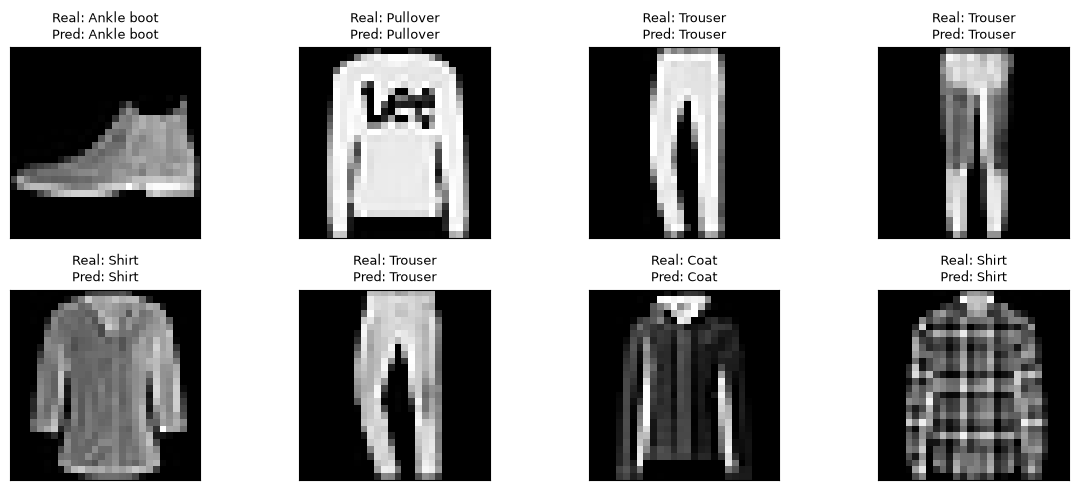

In [13]:
# Visualizamos algunas predicciones.
n = 8
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.convert_to_numpy(
    keras.ops.argmax(logits_batch, axis=1)
)

fig = plt.figure(figsize=(12, 5))

for i in range(n):
    plt.subplot(2, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    plt.title(
        f"Real: {class_names[y_test[i]]}\n"
        f"Pred: {class_names[predictions[i]]}",
        fontsize=9,
    )
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


---
## 6. Conclusiones y próximos pasos

### Resultados esperados

Los valores exactos dependen de la inicialización y del entrenamiento, pero normalmente veremos una diferencia clara entre ambos modelos:

| Modelo | Accuracy en prueba (aprox.) | Parámetros |
|---|---:|---:|
| Regresión Logística | ~83–85% | 7,850 |
| **FC Neural Network** (784→128→10) | **~87–89%** | 101,770 |

La red neuronal FC tiene mayor capacidad que la regresión logística porque la combinación:

```text
Dense(128) → ReLU
```

introduce una transformación no lineal del espacio de entrada.

Fashion-MNIST permite ver mejor esta diferencia que MNIST porque varias clases son visualmente similares y no pueden separarse tan fácilmente mediante una transformación lineal.

### Conceptos que vimos

```text
Datos
  ↓
mini-batches
  ↓
Forward pass
  ↓
Logits
  ↓
Cross-Entropy Loss
  ↓
Backpropagation
  ↓
Adam
  ↓
Actualización de parámetros
```

Keras 3 encapsula este ciclo con:

```python
model.compile(...)
model.fit(...)
model.evaluate(...)
```

pero los conceptos matemáticos subyacentes siguen siendo los mismos.

### Experimentos sugeridos

- Cambia `MODEL_TYPE = "fc"` y compara con la regresión logística.
- Identifica cuáles clases se confunden más.
- Añade una segunda capa oculta.
- Cambia `relu` por `tanh` o `sigmoid`.
- Cambia `batch_size`.
- Prueba distintos valores de `lr_rate`.
- Aumenta o reduce el número de epochs.
- Añade `Dropout`.
- Compara train accuracy y test accuracy.
- Como siguiente paso, compara esta red fully-connected con una **CNN**, que aprovecha explícitamente la estructura espacial de las imágenes.

---

### Equivalencias principales: PyTorch → Keras 3

| PyTorch | Keras 3 |
|---|---|
| `torchvision.datasets.FashionMNIST` | `keras.datasets.fashion_mnist.load_data()` |
| `DataLoader` | `model.fit(..., batch_size=...)` |
| `torch.nn.Linear` | `layers.Dense` |
| `torch.nn.functional.relu` | `activation="relu"` |
| `CrossEntropyLoss` | `SparseCategoricalCrossentropy(from_logits=True)` |
| `torch.optim.Adam` | `keras.optimizers.Adam` |
| `loss.backward()` | autodiferenciación interna durante `fit()` |
| `optimizer.step()` | actualización interna durante `fit()` |
| `torch.argmax` | `keras.ops.argmax` |
| `torch.nn.functional.softmax` | `keras.ops.softmax` |
| `model.eval()` + `no_grad()` | `model.evaluate()` o `model(..., training=False)` |


---
## 7. Mis experimentos

Hago varios de los experimentos sugeridos cambiando una sola cosa a la vez frente a la red FC base (Dense(128) con ReLU, Adam con lr 0.001, batch 64 y 10 epochs). El modelo de regresión logística ya quedó entrenado arriba.

In [14]:
def crear_fc(capas=(128,), activacion="relu", dropout=0.0):
    modelo = keras.Sequential()
    modelo.add(keras.Input(shape=input_shape))
    modelo.add(layers.Flatten())
    for n in capas:
        modelo.add(layers.Dense(n, activation=activacion))
        if dropout > 0:
            modelo.add(layers.Dropout(dropout))
    modelo.add(layers.Dense(output_dim))
    return modelo


def entrenar(modelo, lr=0.001, bs=64, ep=10):
    keras.utils.set_random_seed(SEED)
    modelo.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=["accuracy"],
    )
    h = modelo.fit(X_train, y_train, validation_data=(X_test, y_test),
                   epochs=ep, batch_size=bs, shuffle=True, verbose=0)
    return h


resultados = {}
resultados["logistica"] = history.history

experimentos = {
    "fc base (relu 128)": dict(modelo=dict(), fit=dict()),
    "dos capas (128, 64)": dict(modelo=dict(capas=(128, 64)), fit=dict()),
    "tanh": dict(modelo=dict(activacion="tanh"), fit=dict()),
    "sigmoid": dict(modelo=dict(activacion="sigmoid"), fit=dict()),
    "dropout 0.3": dict(modelo=dict(dropout=0.3), fit=dict()),
    "batch 256": dict(modelo=dict(), fit=dict(bs=256)),
    "lr 0.01": dict(modelo=dict(), fit=dict(lr=0.01)),
}

modelos = {}
for nombre, cfg in experimentos.items():
    keras.utils.set_random_seed(SEED)
    m = crear_fc(**cfg["modelo"])
    h = entrenar(m, **cfg["fit"])
    modelos[nombre] = m
    resultados[nombre] = h.history
    print(f"{nombre:22s} train acc = {h.history['accuracy'][-1]:.4f}   test acc = {h.history['val_accuracy'][-1]:.4f}   params = {m.count_params():,}")

fc base (relu 128)     train acc = 0.9115   test acc = 0.8731   params = 101,770


dos capas (128, 64)    train acc = 0.9122   test acc = 0.8772   params = 109,386


tanh                   train acc = 0.9136   test acc = 0.8741   params = 101,770


sigmoid                train acc = 0.9022   test acc = 0.8744   params = 101,770


dropout 0.3            train acc = 0.8871   test acc = 0.8733   params = 101,770


batch 256              train acc = 0.8983   test acc = 0.8676   params = 101,770


lr 0.01                train acc = 0.8758   test acc = 0.8514   params = 101,770


experimento               train     test  diferencia  mejor test
logistica                0.8625   0.8442      0.0183      0.8442
fc base (relu 128)       0.9115   0.8731      0.0384      0.8783
dos capas (128, 64)      0.9122   0.8772      0.0350      0.8785
tanh                     0.9136   0.8741      0.0395      0.8763
sigmoid                  0.9022   0.8744      0.0278      0.8744
dropout 0.3              0.8871   0.8733      0.0138      0.8791
batch 256                0.8983   0.8676      0.0307      0.8690
lr 0.01                  0.8758   0.8514      0.0244      0.8540


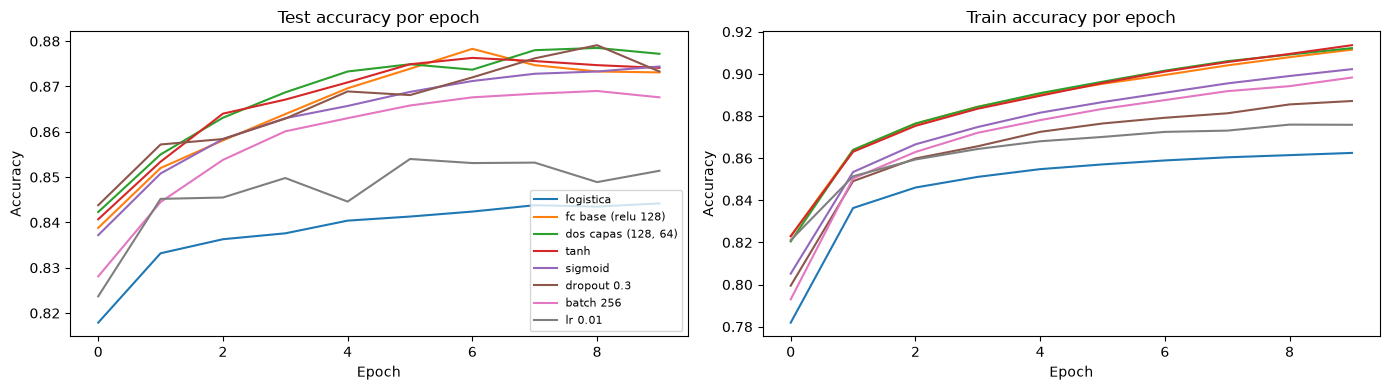

In [15]:
print(f"{'experimento':22s} {'train':>8s} {'test':>8s} {'diferencia':>11s} {'mejor test':>11s}")
for nombre, h in resultados.items():
    tr = h["accuracy"][-1]
    te = h["val_accuracy"][-1]
    print(f"{nombre:22s} {tr:8.4f} {te:8.4f} {tr - te:11.4f} {max(h['val_accuracy']):11.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for nombre, h in resultados.items():
    axes[0].plot(h["val_accuracy"], label=nombre)
    axes[1].plot(h["accuracy"], label=nombre)
axes[0].set_title("Test accuracy por epoch")
axes[1].set_title("Train accuracy por epoch")
for ax in axes:
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Accuracy")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

Accuracy por clase:
  T-shirt/top  0.833
  Trouser      0.961
  Pullover     0.852
  Dress        0.857
  Coat         0.742
  Sandal       0.956
  Shirt        0.669
  Sneaker      0.971
  Bag          0.945
  Ankle boot   0.945

Confusiones mas frecuentes (real, predicha, cantidad):
  Coat         Pullover     172
  Shirt        T-shirt/top  132
  T-shirt/top  Shirt        123
  Shirt        Pullover     119
  Pullover     Coat         64
  Shirt        Coat         60


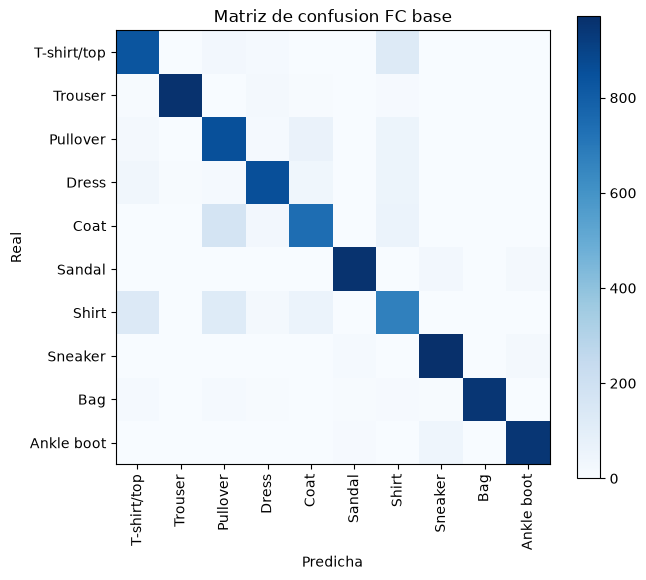

In [16]:
# clases que mas se confunden con la red fc base
fc_base = modelos["fc base (relu 128)"]
pred = np.argmax(fc_base.predict(X_test, verbose=0), axis=1)

conf = np.zeros((10, 10), dtype=int)
for t, p in zip(y_test, pred):
    conf[t, p] += 1

print("Accuracy por clase:")
for c in range(10):
    print(f"  {class_names[c]:12s} {conf[c, c] / conf[c].sum():.3f}")

errores = conf.copy()
np.fill_diagonal(errores, 0)
orden = np.argsort(errores.ravel())[::-1][:6]
print("\nConfusiones mas frecuentes (real, predicha, cantidad):")
for k in orden:
    t, p = divmod(k, 10)
    print(f"  {class_names[t]:12s} {class_names[p]:12s} {errores[t, p]}")

plt.figure(figsize=(7, 6))
plt.imshow(conf, cmap="Blues")
plt.colorbar()
plt.xticks(range(10), class_names, rotation=90)
plt.yticks(range(10), class_names)
plt.xlabel("Predicha")
plt.ylabel("Real")
plt.title("Matriz de confusion FC base")
plt.show()

### Conclusiones de los experimentos

**FC contra regresión logística:** la regresión logística llegó a 84.42 % en test y la red FC base a 87.31 %, casi 3 puntos más. La red tiene muchos más parámetros (101,770 contra 7,850) y gracias a ReLU puede hacer fronteras no lineales, entonces separa mejor las prendas parecidas. A cambio la diferencia entre train y test es mayor (3.8 puntos contra 1.8), o sea que ya empieza a sobreajustar un poco.

**Clases que más se confunden:** la peor clase es Shirt con 66.9 % y después Coat con 74.2 %. Las confusiones más frecuentes fueron Coat predicho como Pullover (172 veces), Shirt como camiseta, que es la clase 0 (132), camiseta como Shirt (123) y Shirt como Pullover (119). Todas son prendas de la parte de arriba con forma parecida, y en 28x28 píxeles en gris casi no se ven detalles como botones o el cuello. En cambio Trouser, Sneaker, Sandal, Bag y Ankle boot pasan del 94 % porque tienen formas muy distintas.

**Segunda capa oculta:** con (128, 64) dio 87.72 %, apenas 0.4 puntos más que la base. Ayuda un poco pero no mucho, el límite parece estar más en que la red trata la imagen como un vector plano.

**Activación:** tanh (87.41 %) y sigmoid (87.44 %) quedaron prácticamente igual que ReLU (87.31 %) con una sola capa oculta. Sigmoid tuvo menos diferencia entre train y test. Con una red tan pequeña la activación no cambia mucho, la diferencia se notaría más en redes profundas.

**Dropout 0.3:** la accuracy final de test fue casi igual (87.33 %) pero la de train bajó a 88.71 %, entonces la brecha entre train y test pasó de 3.8 a 1.4 puntos. Además tuvo el mejor test de todas las epochs (87.91 %). Dropout sí reduce el overfitting.

**Batch size 256:** bajó a 86.76 %. Con batches más grandes hay menos actualizaciones por epoch (235 en vez de 938), entonces en 10 epochs alcanza a aprender menos.

**Learning rate 0.01:** fue el peor de las redes, 85.14 %, incluso con menor accuracy de train. El paso es muy grande y Adam salta alrededor del mínimo en vez de bajar bien.

En resumen, lo que más ayudó fue pasar de modelo lineal a la red con capa oculta, y Dropout fue lo mejor para controlar el overfitting. Para mejorar de verdad en las clases de ropa parecidas tocaría usar una CNN que aproveche la estructura espacial.